<a href="https://colab.research.google.com/github/Nehuenpg/CV/blob/main/ML-UNS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
'''Bibliotecas'''
import math
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import requests
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import gaussian_kde

# **Clase 1**






---


# **Ejercicio 1**

---



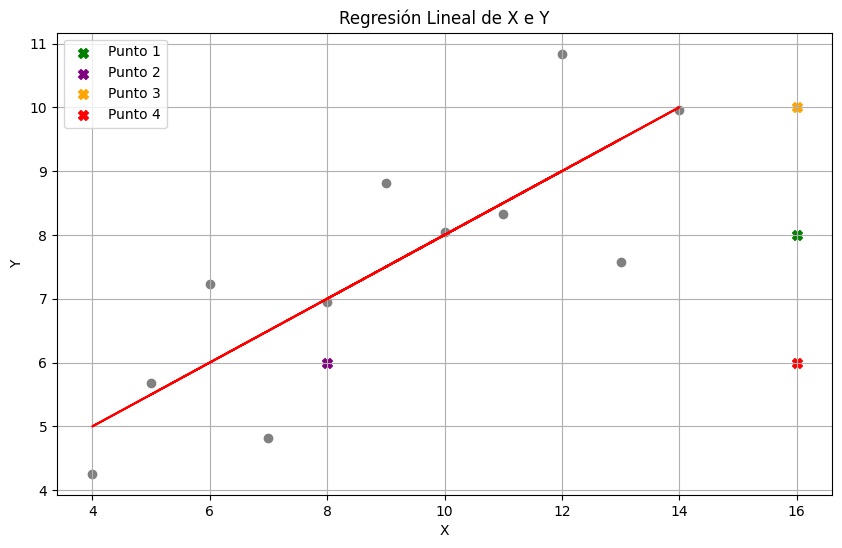

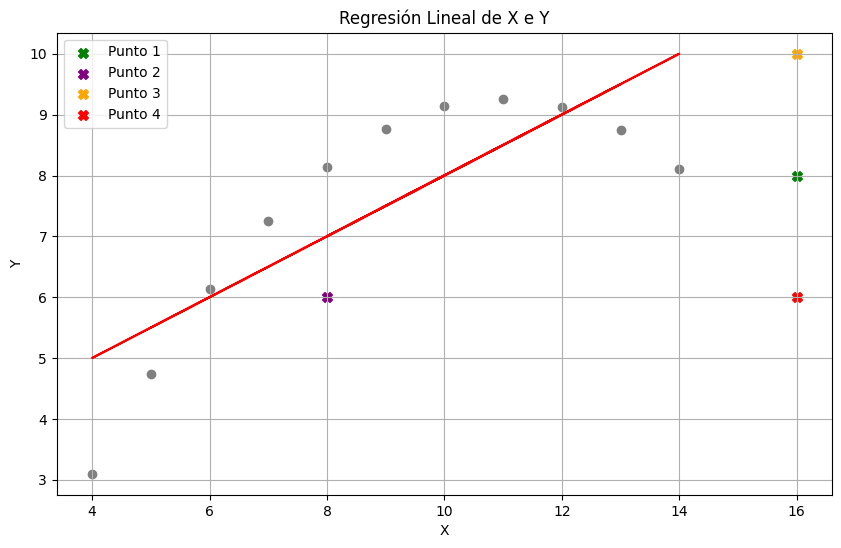

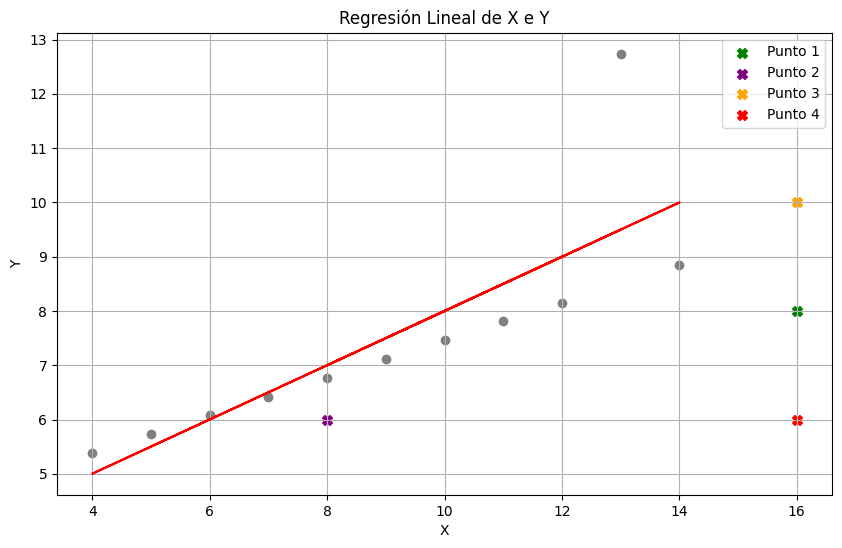

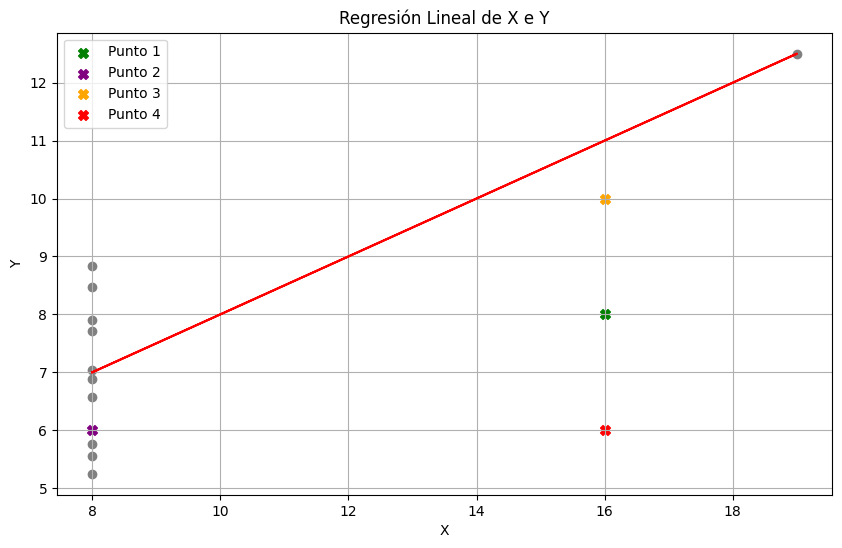

In [85]:
'''Puntos de los 4 gráficos'''

x_I = [10,8,13,9,11,14,6,4,12,7,5]
y_I = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]

x_II = [10,8,13,9,11,14,6,4,12,7,5]
y_II = [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]

x_III = [10,8,13,9,11,14,6,4,12,7,5]
y_III = [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]

x_IV = [8,8,8,8,8,8,8,19,8,8,8]
y_IV = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]

puntos_incognitas = ([16,8],[8,6],[16,10],[16,6])

puntos = {'I' : (x_I,y_I),'II': (x_II,y_II),'III': (x_III,y_III),'IV':(x_IV,y_IV)}

for punto in puntos:

  # Datos de ejemplo
  x = puntos[punto][0]
  y = puntos[punto][1]

  '''Cálculos estadísticos'''
  media_x = round(np.mean(x),2)
  media_y = round(np.mean(y),2)
  varianza_x = round(np.var(x, ddof=1),2)
  varianza_y = round(np.var(y, ddof=1),2)
  correlacion = round(np.corrcoef(x, y)[0, 1],2)

  # Regresión lineal
  slope, intercept, r_value, p_value, std_err = linregress(x, y)
  r_squared = round(r_value**2,2)

  '''Gráfico de los puntos y la línea de regresión'''
  plt.figure(figsize=(10, 6))
  plt.scatter(x, y, color='grey')  # Gráfico de los puntos
  plt.plot(x, intercept + slope * np.array(x), color='red')  # Línea de regresión


  # Agregar puntos manuales con distintos colores
  manual_points = {
    'Punto 1': {'x': 16, 'y': 8, 'color': 'green'},
    'Punto 2': {'x': 8, 'y': 6, 'color': 'purple'},
    'Punto 3': {'x': 16, 'y': 10, 'color': 'orange'},
    'Punto 4': {'x': 16, 'y': 6, 'color': 'red'} }

  # Graficar cada punto manualmente
  for label, point in manual_points.items():
      plt.scatter(point['x'], point['y'], color=point['color'], label=label, s=50, marker='X')

  '''Etiquetas y título'''
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.title('Regresión Lineal de X e Y')

  plt.legend()

  '''Mostrar gráfico'''
  plt.grid(True)
  plt.show()

**Observandon la distribución de los puntos en los gráficos podemos observar a que gráfico corresponde cada uno:**

1.   Punto Verde (16,8), pertenece al primer Data Set.
2.   Punto Violeta (8,6), pertenece al cuarto Data Set.
3.  Punto Amarillo (16,10), pertenece al tercer Data Set.
4. Punto Rojo (16,6), pertenece al segundo Data Set.



#**Clase 2**

---


# **Ejercicio 1**


---



# **Casos Covid Bahia**

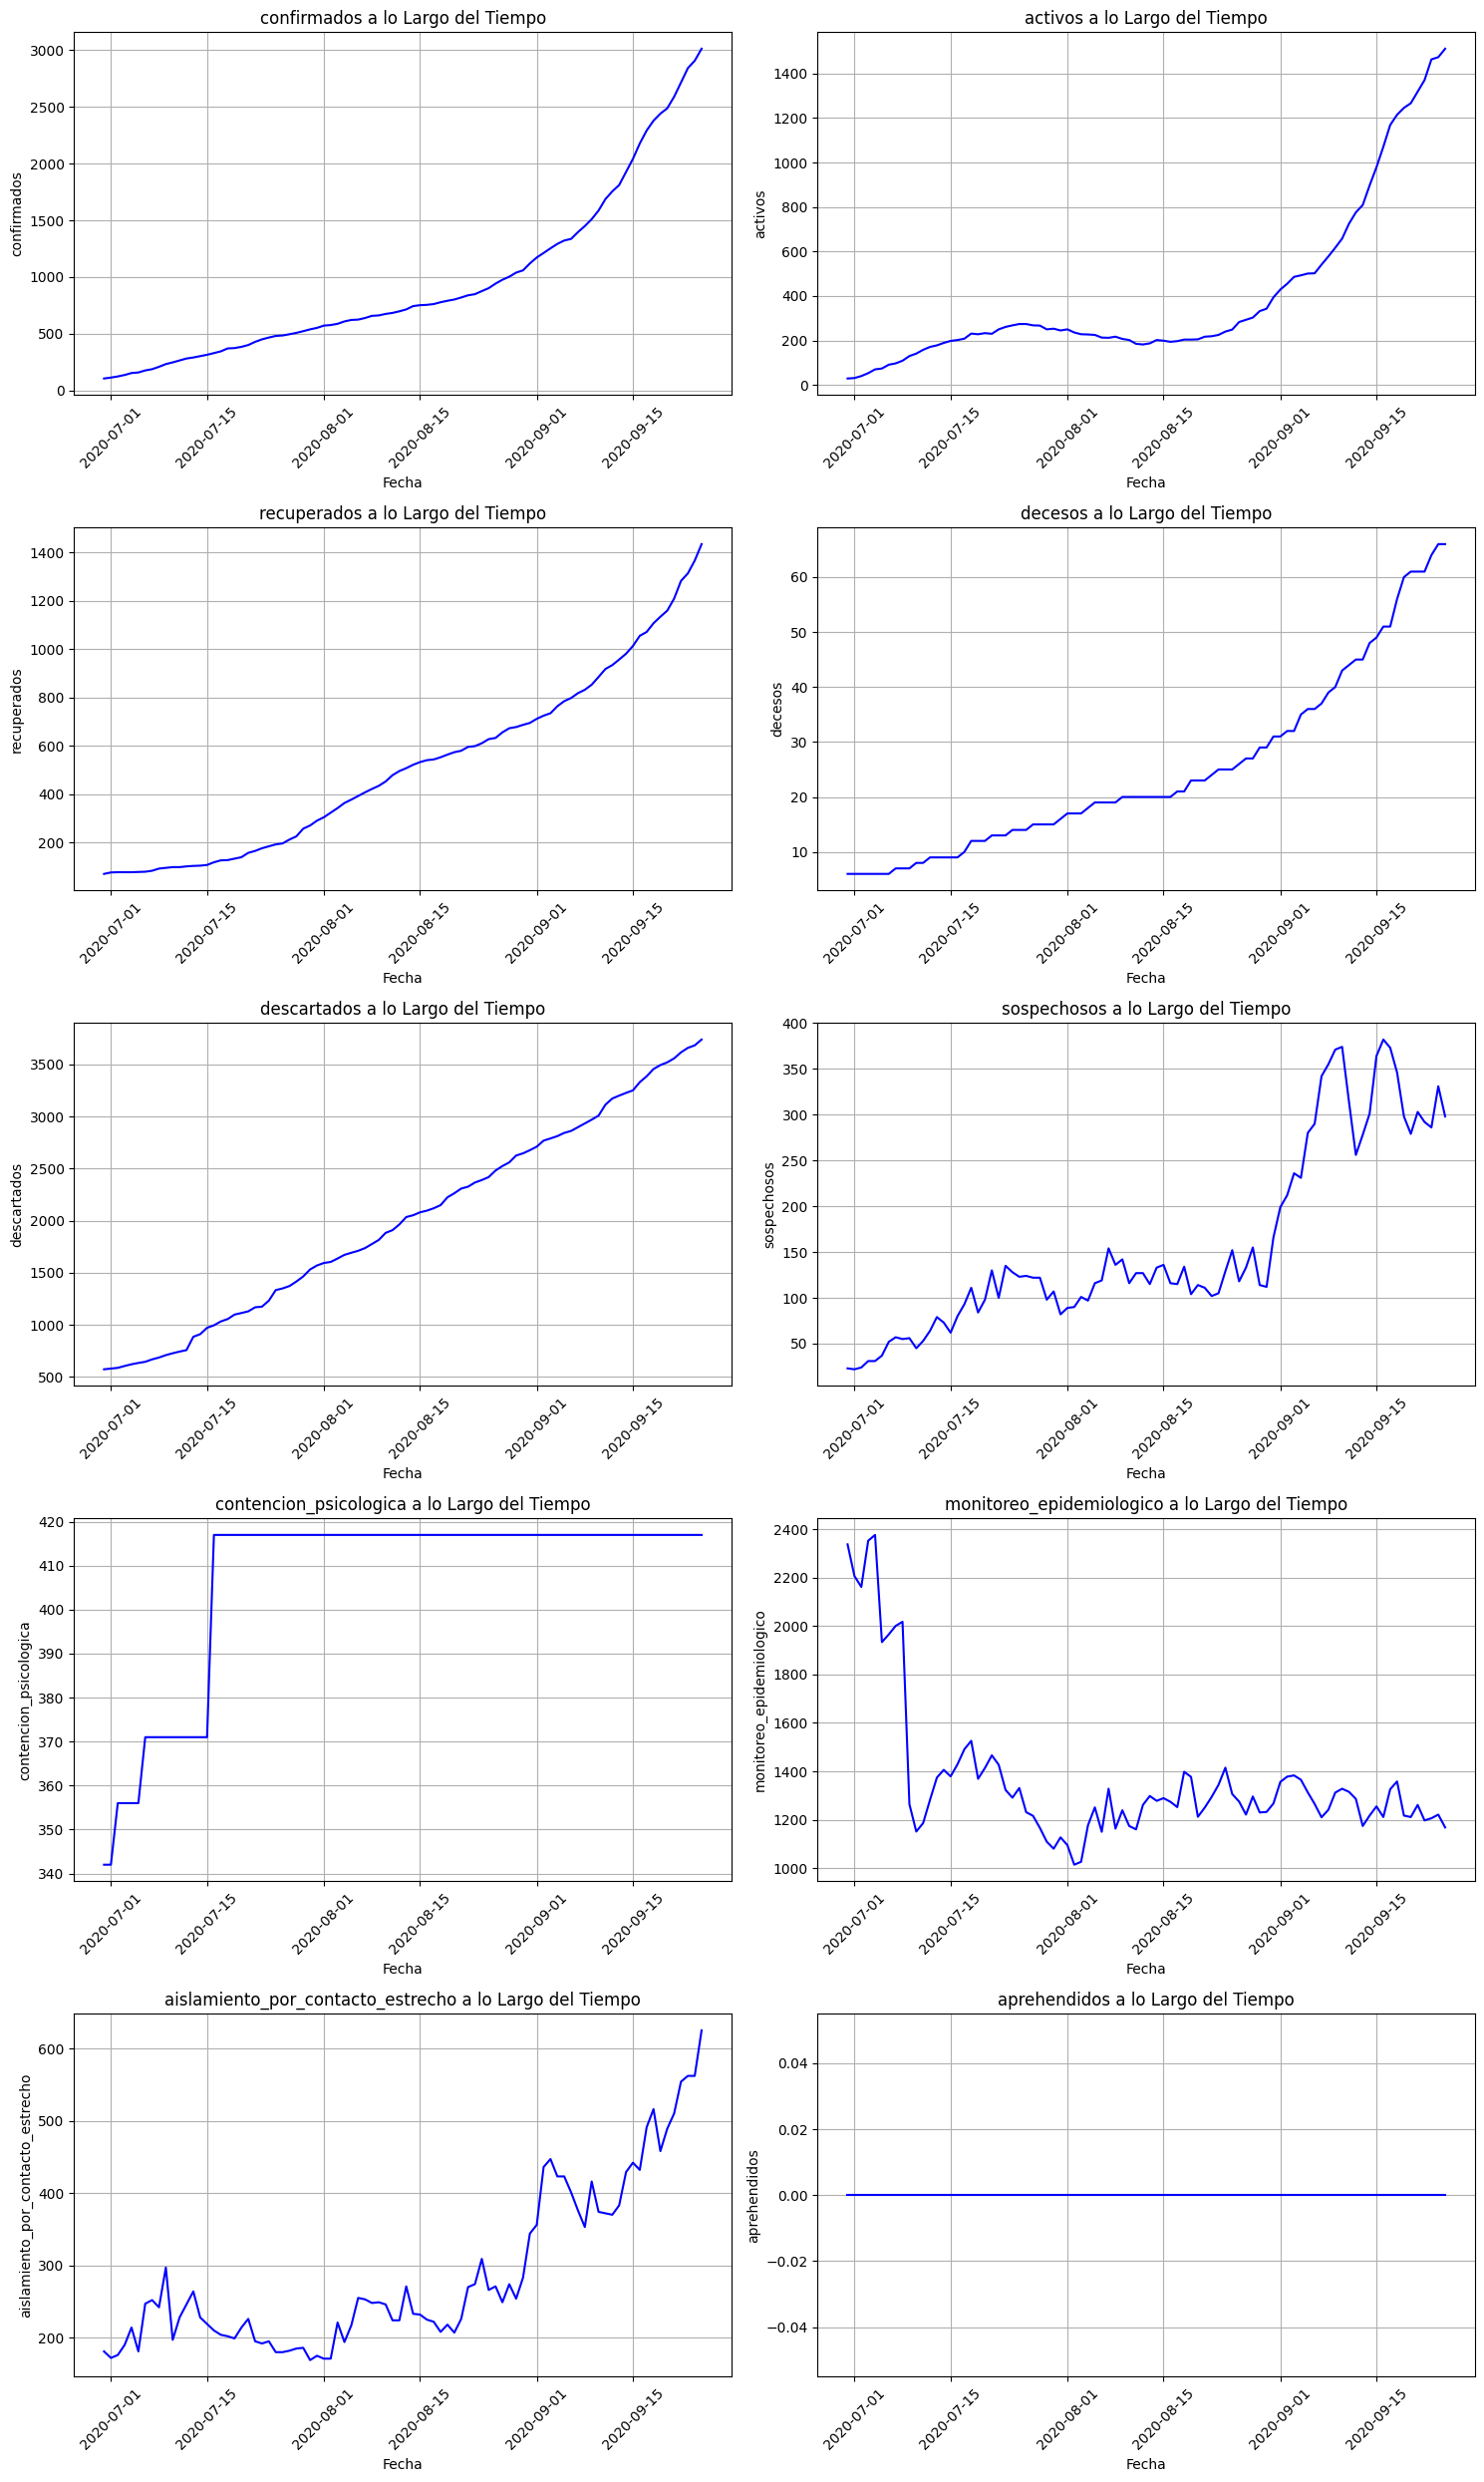

In [86]:
url_casos_covid = 'https://raw.githubusercontent.com/manlio99/Materia-de-aprendizaje/master/4_DataWrangling/data/casos_covid_bahia.csv'

df_casos = pd.read_csv(url_casos_covid)

df_casos_columnas = df_casos.columns[1:]

# Asegúrate de que la columna 'fecha' esté en formato datetime
df_casos['fecha'] = pd.to_datetime(df_casos['fecha'])

# Número de gráficos por fila
n_cols = 2
n_rows = (len(df_casos_columnas) + n_cols - 1) // n_cols  # Calcula el número de filas necesarias

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# Crear los gráficos
for i, col in enumerate(df_casos_columnas):
    sns.lineplot(data=df_casos, x='fecha', y=col, color='blue', ax=axes[i])

    # Personalizar el gráfico
    axes[i].set_title(f'{col} a lo Largo del Tiempo')
    axes[i].set_xlabel('Fecha')
    axes[i].set_ylabel(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotea las etiquetas del eje X si es necesario
    axes[i].grid(True)

# Elimina los subgráficos no utilizados si hay menos datos de columnas que gráficos
for j in range(len(df_casos_columnas), len(axes)):
    fig.delaxes(axes[j])

# Ajustar el diseño para que no se corten las etiquetas
plt.tight_layout()
plt.show()



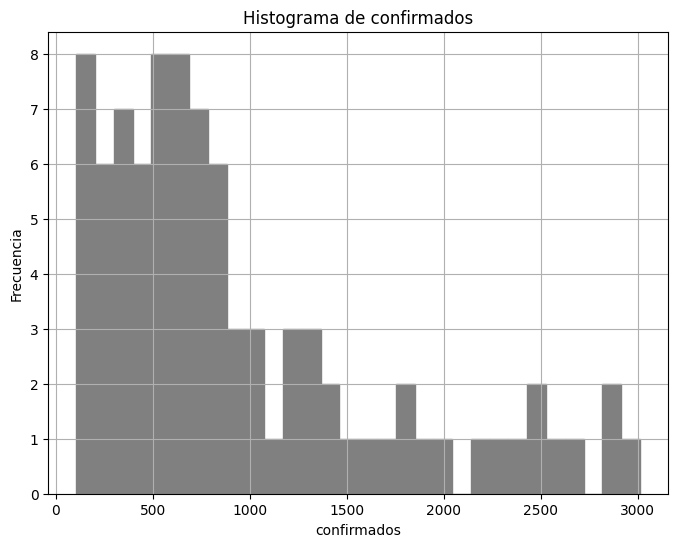

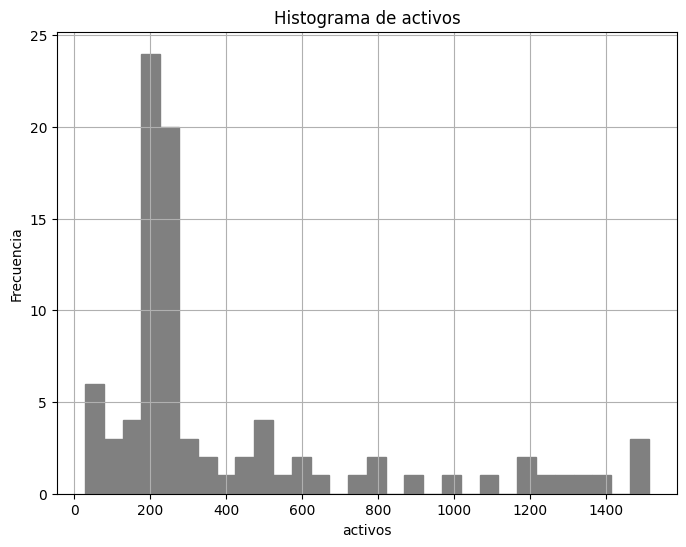

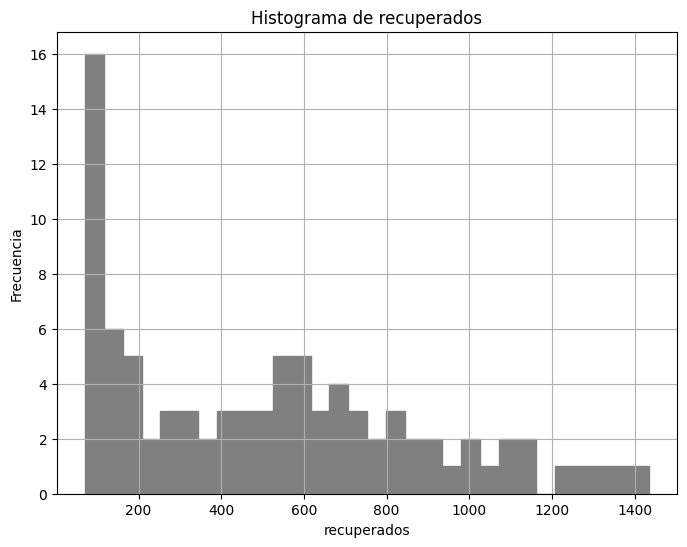

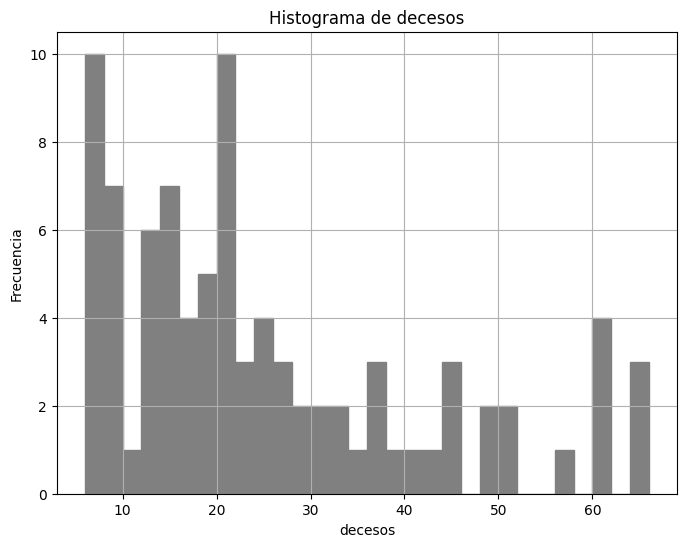

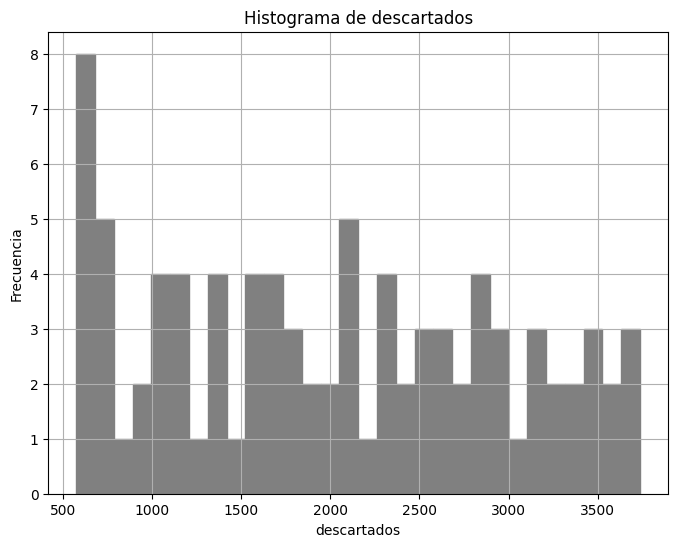

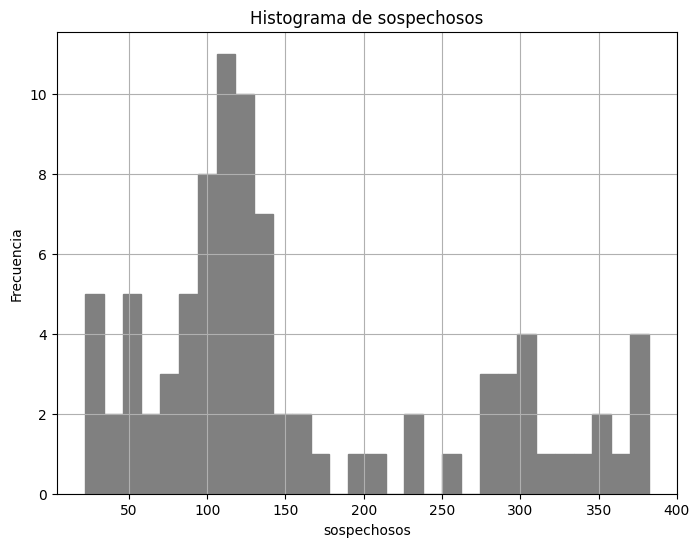

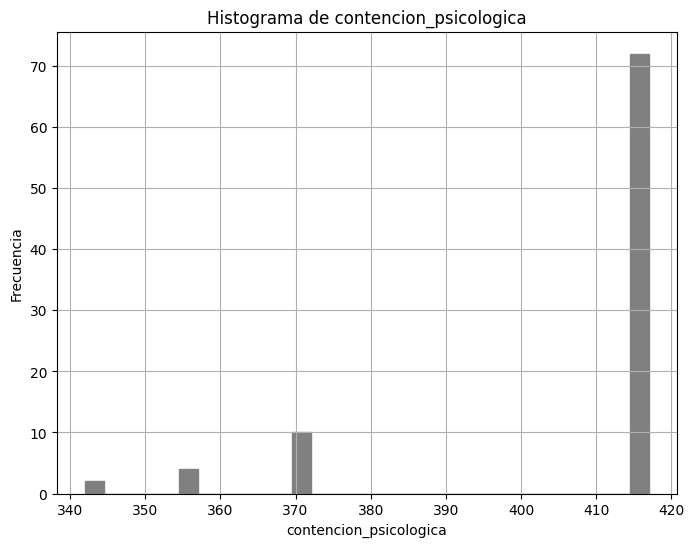

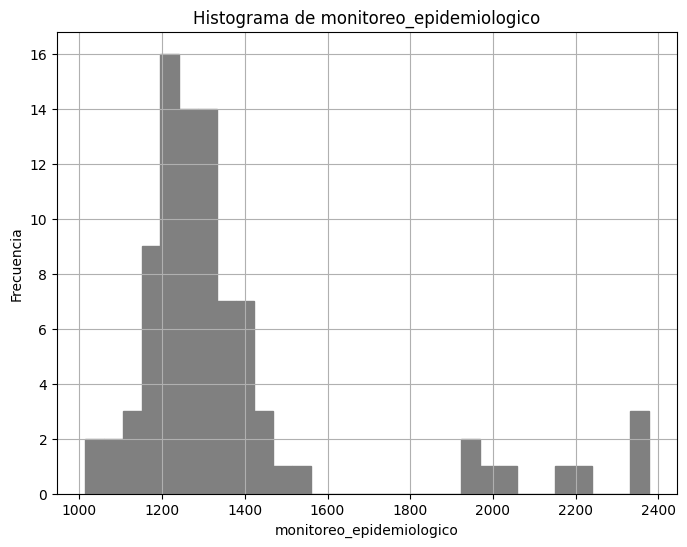

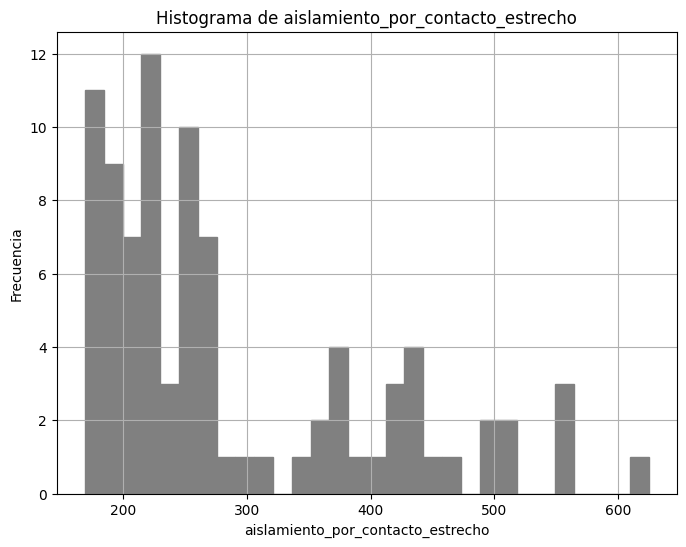

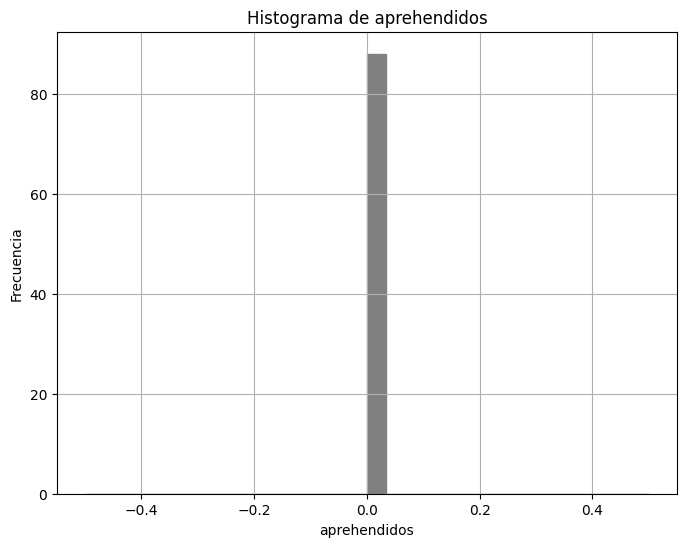

In [87]:
# Iterar sobre cada columna numérica del DataFrame df_casos
for column in df_casos.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df_casos[column], bins=30, color='Grey', edgecolor='Grey')
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()

# **Camas Covid Bahia**

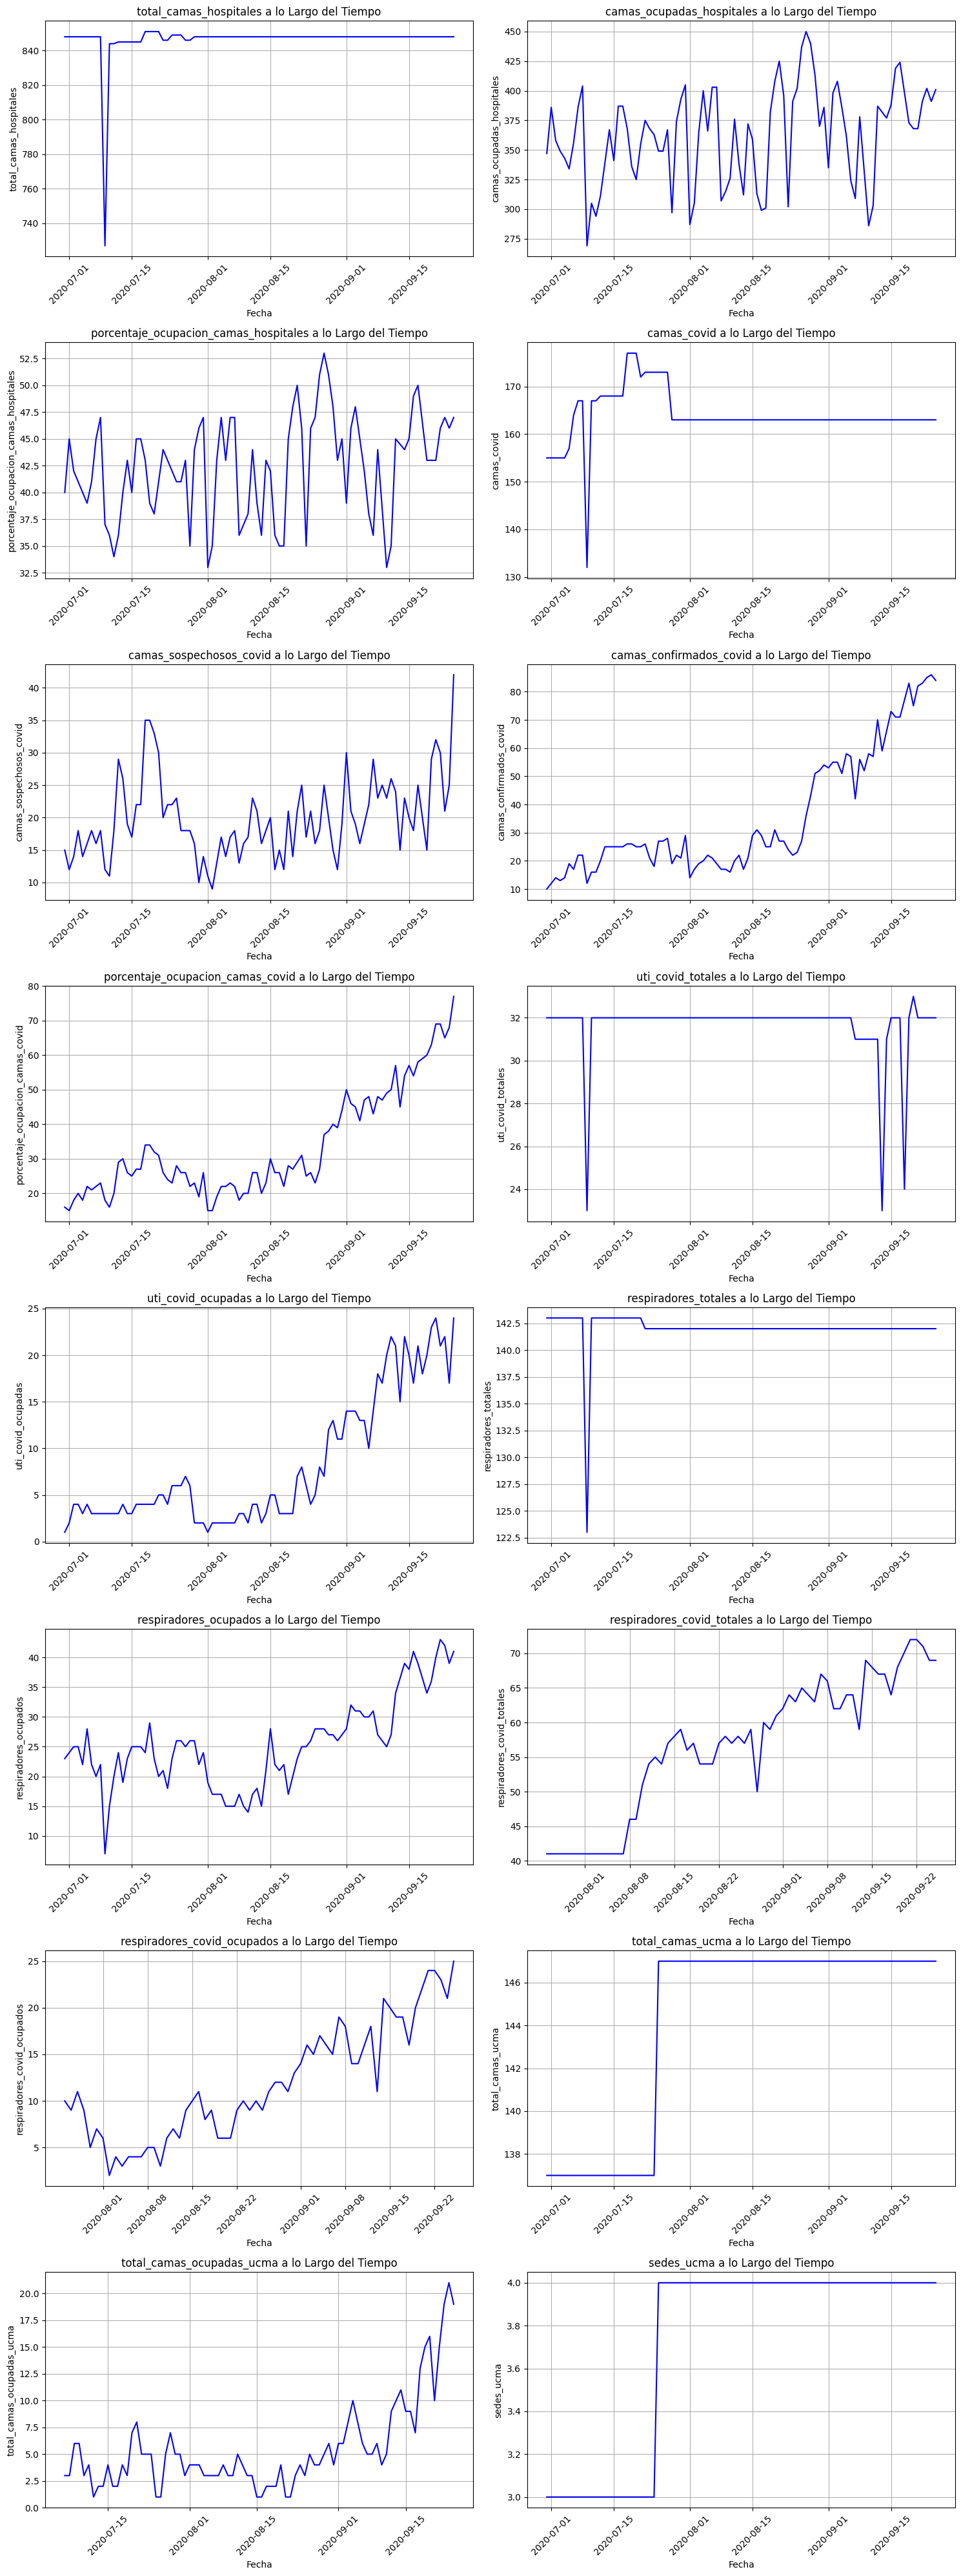

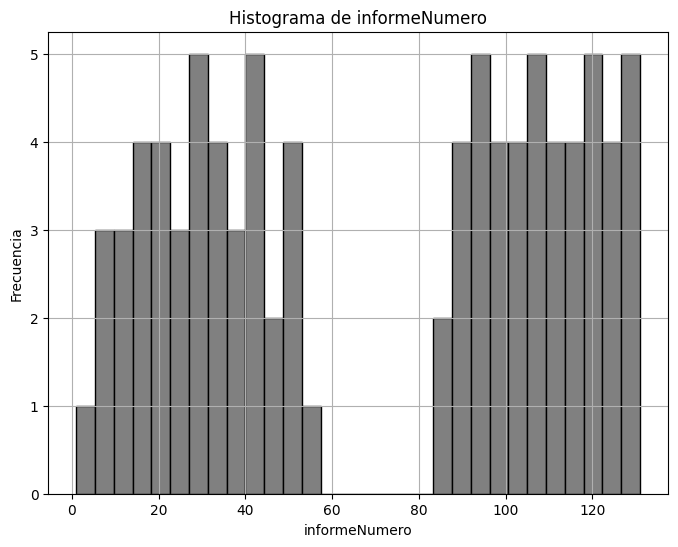

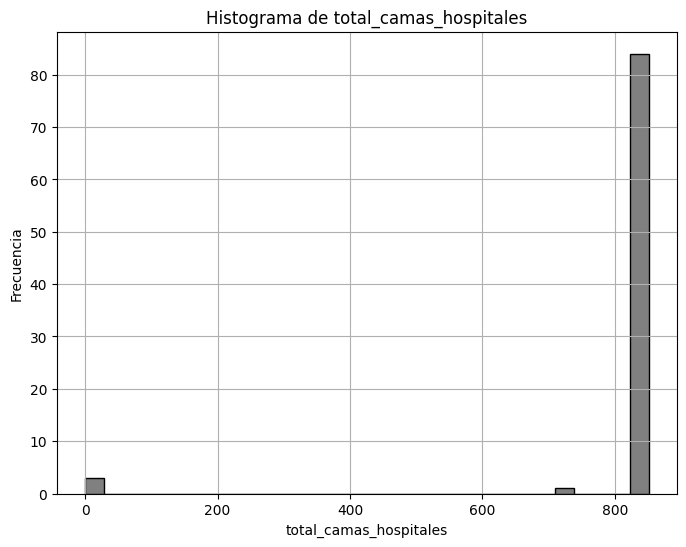

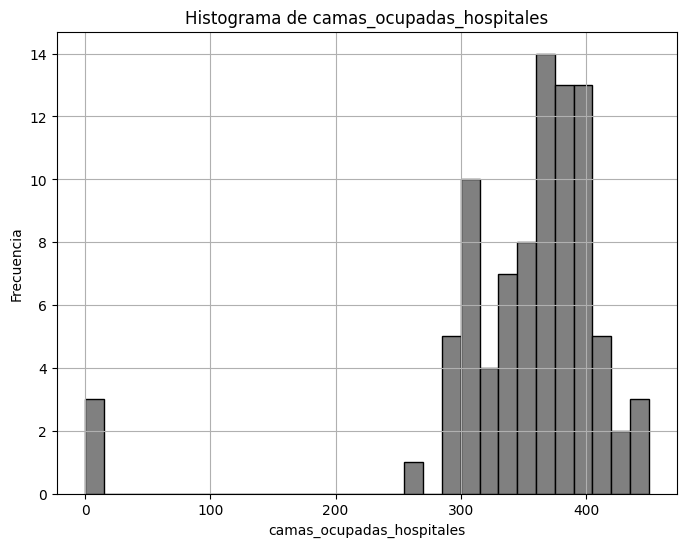

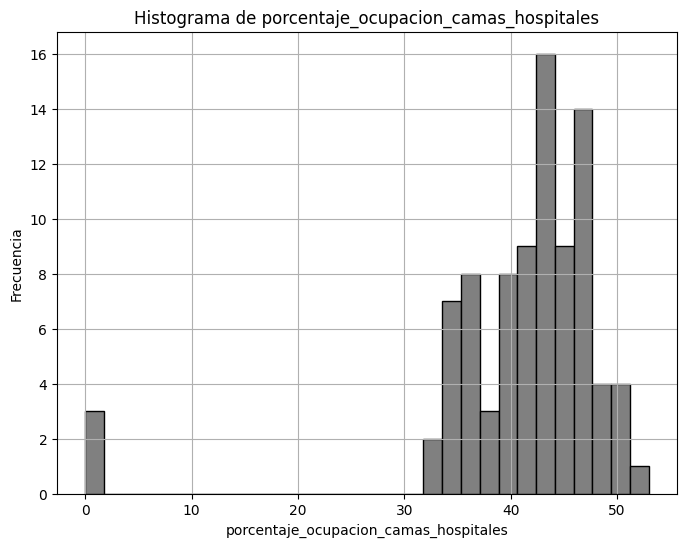

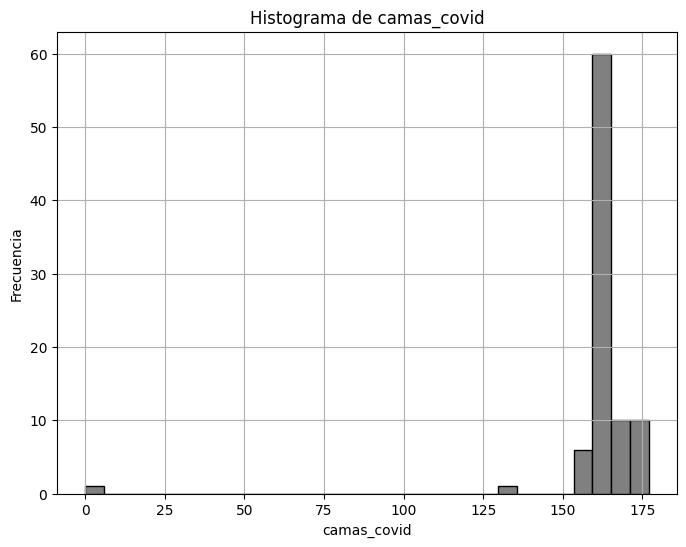

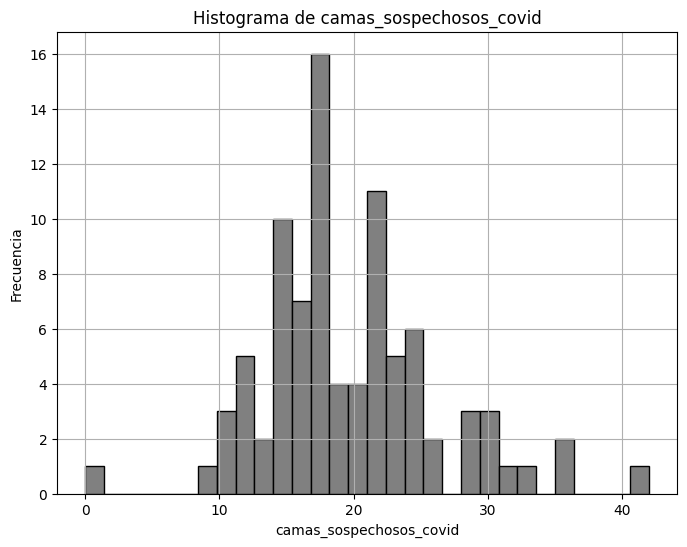

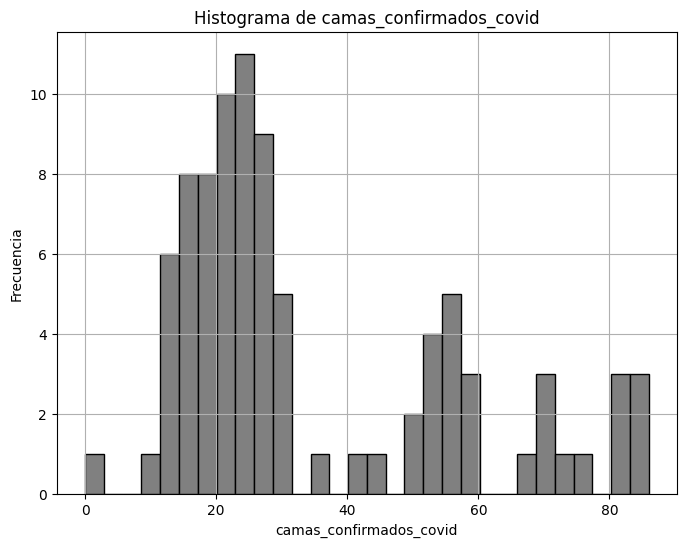

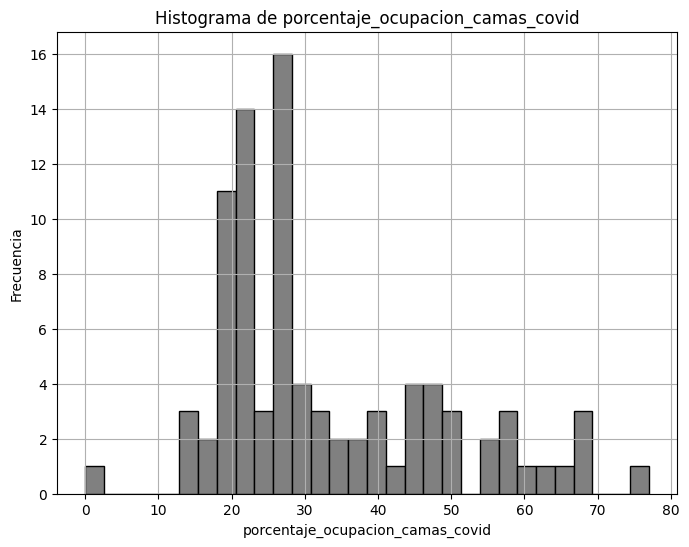

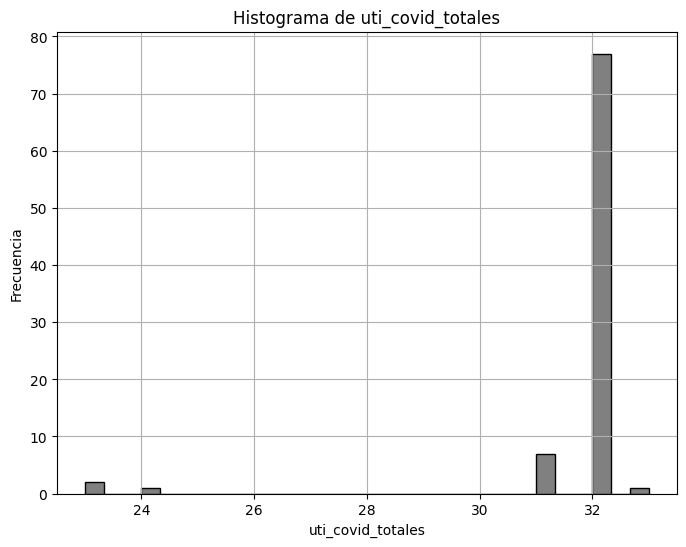

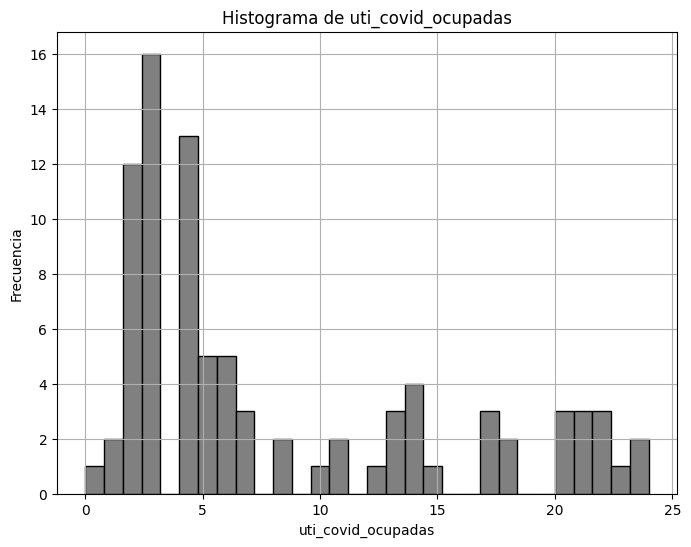

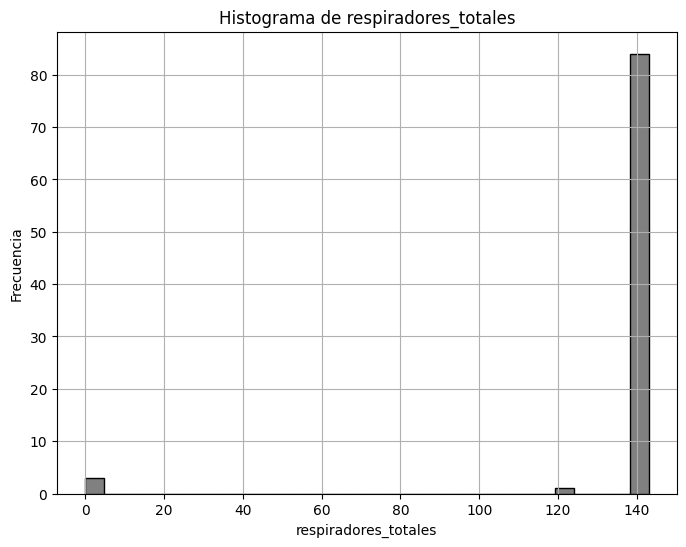

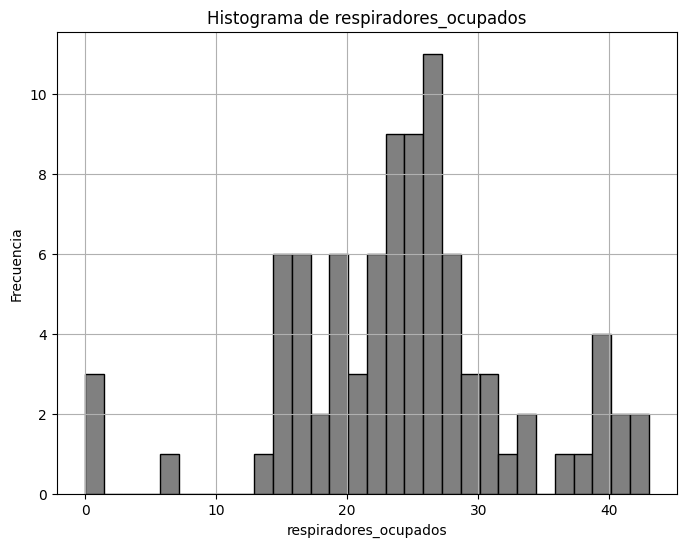

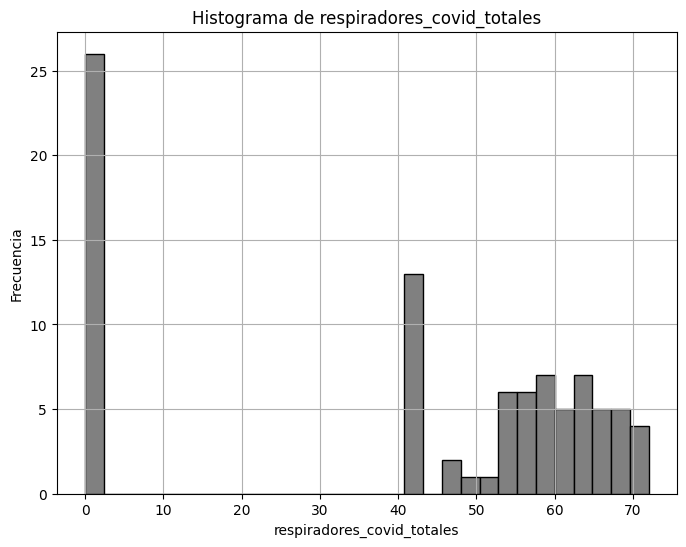

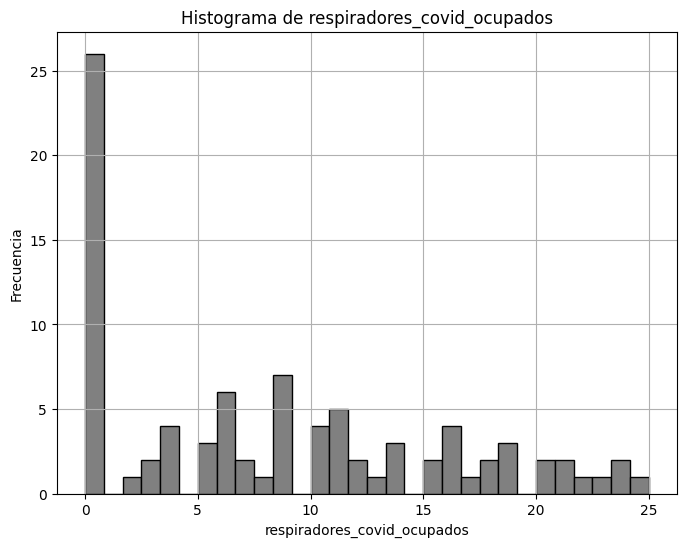

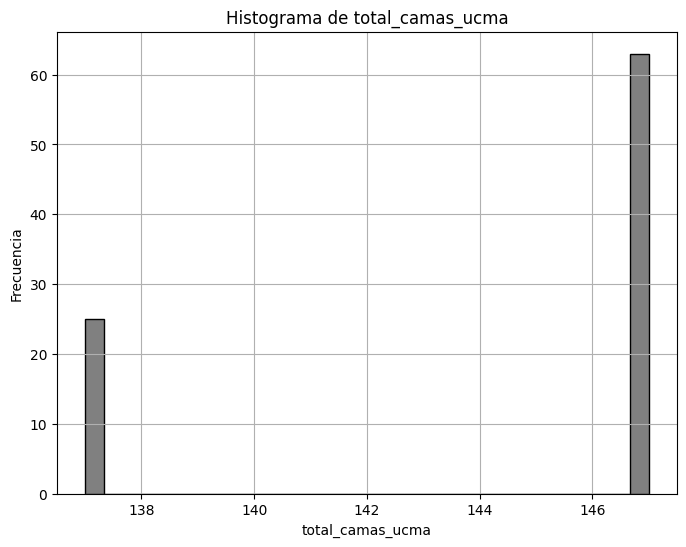

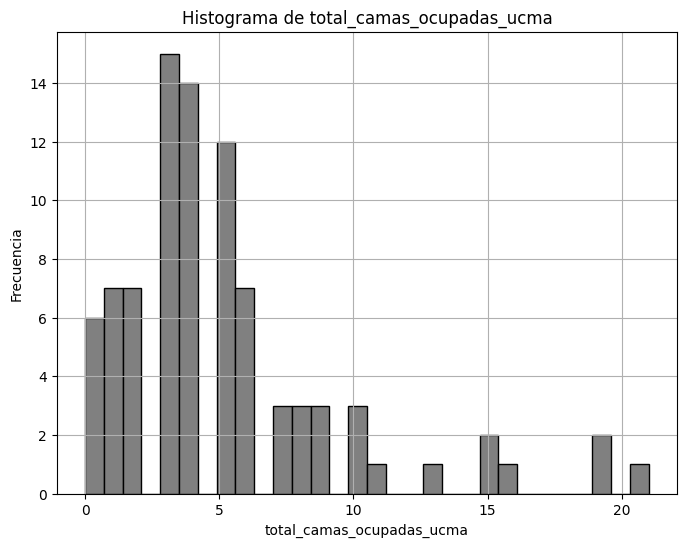

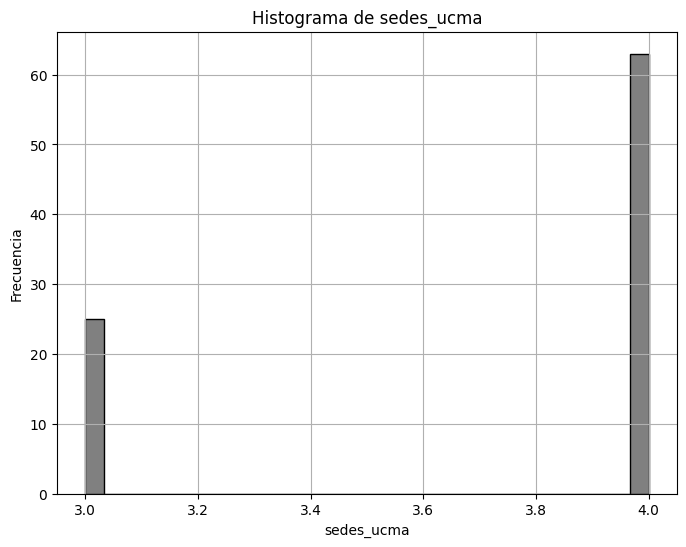

In [88]:
url_camas_covid = 'https://raw.githubusercontent.com/manlio99/Materia-de-aprendizaje/master/4_DataWrangling/data/camas_covid_bahia.csv'

df_camas = pd.read_csv(url_camas_covid)

df_camas['fecha'] = pd.to_datetime(df_camas['fecha'])

df_camas_columnas = df_camas.columns[2:-1]

# Número de gráficos por fila
n_cols = 2
n_rows = (len(df_camas_columnas) + n_cols - 1) // n_cols  # Calcula el número de filas necesarias

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# Crear los gráficos
plot_count = 0
for i, col in enumerate(df_camas_columnas):
    data_filtered = df_camas[df_camas[col] > 0]

    if not data_filtered.empty:
        sns.lineplot(data=data_filtered, x='fecha', y=col, color='blue', ax=axes[plot_count])

        # Personalizar el gráfico
        axes[plot_count].set_title(f'{col} a lo Largo del Tiempo')
        axes[plot_count].set_xlabel('Fecha')
        axes[plot_count].set_ylabel(f'{col}')
        axes[plot_count].tick_params(axis='x', rotation=45)  # Rotea las etiquetas del eje X si es necesario
        axes[plot_count].grid(True)

        plot_count += 1

# Elimina los subgráficos no utilizados si hay menos datos de columnas que gráficos
for j in range(len(df_camas_columnas), len(axes)):
    fig.delaxes(axes[j])

# Ajustar el diseño para que no se corten las etiquetas
plt.tight_layout()
plt.show()

for column in df_camas.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df_camas[column], bins=30, color='Grey', edgecolor='black')
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()






---

# **Ejercicio 2**


---



Generar un dataset similar al de la pág. 12 de este
apunte (dos conjuntos Gaussianos con diferente media y DS,
N=50 c/u, uno con etiqueta A y otro con etiqueta B).
Utilizar la curva ROC para proponer un umbral para un clasificador
por mínimo error. Evaluar algunos de los parámetros de calidad
(exactitud, precisión, f-measure).
Recalcular para algunas variantes (por ejemplo, acercando las
medias de los grupos A y B, cambiando el valor umbral, etc.).
Cómo podrían hacer no supervisado este proceso?

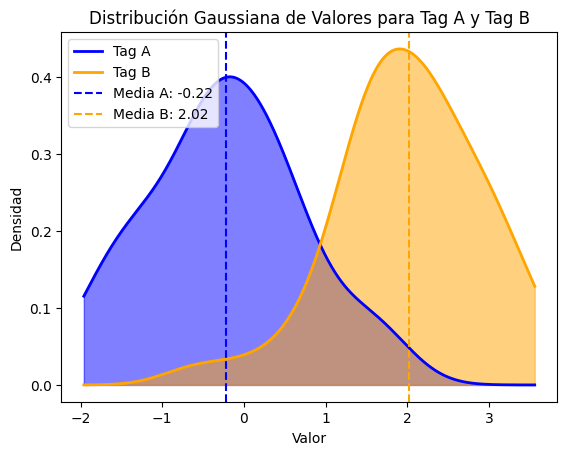

            Value
count  100.000000
mean     0.896300
std      1.442006
min     -1.960000
25%     -0.245000
50%      0.975000
75%      2.030000
max      3.560000


In [151]:
# Generar 50 valores aleatorios para Tag A y Tag B
np.random.seed(42)  # Fijar la semilla para reproducibilidad
values_A = np.round(np.random.normal(loc=0, scale=1, size=50),2)  # Datos para A (distribución normal)
values_B = np.round(np.random.normal(loc=2, scale=1, size=50),2)  # Datos para B (distribución normal)

# Crear las etiquetas correspondientes
tags_A = ['A'] * 50
tags_B = ['B'] * 50

# Crear el DataFrame
data = {
    'Tag': ['A'] * 50 + ['B'] * 50,
    'Value': np.concatenate([values_A, values_B])
}
df = pd.DataFrame(data)

# Separar los valores por Tag
x_A = df[df['Tag'] == 'A']['Value']
x_B = df[df['Tag'] == 'B']['Value']

# Crear la figura y los ejes
fig, ax = plt.subplots()

# Calcular la densidad (KDE) para A y B
kde_A = gaussian_kde(x_A)
kde_B = gaussian_kde(x_B)

# Generar un rango de valores para el eje X
x_range = np.linspace(min(df['Value']), max(df['Value']), 1000)

# Graficar la densidad para el conjunto A
ax.plot(x_range, kde_A(x_range), color='blue', label='Tag A', lw=2)
ax.fill_between(x_range, kde_A(x_range), color='blue', alpha=0.5)

# Graficar la densidad para el conjunto B
ax.plot(x_range, kde_B(x_range), color='orange', label='Tag B', lw=2)
ax.fill_between(x_range, kde_B(x_range), color='orange', alpha=0.5)

# Agregar líneas verticales en las medias
ax.axvline(np.mean(x_A), color='blue', linestyle='--', label=f'Media A: {np.mean(x_A):.2f}')
ax.axvline(np.mean(x_B), color='orange', linestyle='--', label=f'Media B: {np.mean(x_B):.2f}')

# Configurar etiquetas y título
ax.set_title('Distribución Gaussiana de Valores para Tag A y Tag B')
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad')

# Mostrar la leyenda
ax.legend()

# Mostrar el gráfico
plt.show()

print(df.describe())

In [152]:
def curva_ROC(min_umbral, max_umbral, paso,df):
  umbrales = []
  i = min(x_A)
  while i < max(x_B):
    umbrales.append(round(i,2))
    i += paso
  fp = []
  fn = []
  tp = []
  tn = []
  tpr_sensibilidad = []
  tnr_especificidad = []
  fpr = []
  exactitud = []

  for umbral in umbrales:
    fp_parcial = 0
    fn_parcial = 0
    tp_parcial = 0
    tn_parcial = 0
    for i in range(len(df)):
        value = df['Value'].iloc[i]
        tag = df['Tag'].iloc[i]

        if value >= umbral:
            if tag == 'B':
                tp_parcial += 1
            else:
                fp_parcial += 1
        else:
            if tag == 'A':
                tn_parcial += 1
            else:
                fn_parcial += 1
    tpr_sensibilidad.append(tp_parcial/(tp_parcial+fn_parcial))

    tnr_especificidad.append(tn_parcial/(tn_parcial+fp_parcial))

    fpr.append(fp_parcial/(fp_parcial+tn_parcial))

    exactitud.append(tn_parcial+tp_parcial/len(df))
    fp.append(fp_parcial)
    fn.append(fn_parcial)
    tp.append(tp_parcial)
    tn.append(tn_parcial)

  data = {'Umbral': umbrales,
    'Verdaderos Positivos': tp,'Falsos Positivos': fp,'Verdaderos Negativos': tn,'Falsos Negativos': fn,
    'TPR(Sensibilidad)': tpr_sensibilidad,'TNR(Especificidad)': tnr_especificidad,'FPR': fpr,'Exactitud': exactitud}

  df_roc = pd.DataFrame(data)

  return df_roc

curva_ROC(min(x_A),max(x_B), 0.2,df)





,Umbral,Verdaderos Positivos,Falsos Positivos,Verdaderos Negativos,Falsos Negativos,TPR(Sensibilidad),TNR(Especificidad),FPR,Exactitud
0,-1.96,50,50,0,0,1.00,0.00,1.00,0.50
1,-1.76,50,48,2,0,1.00,0.04,0.96,2.50
2,-1.56,50,46,4,0,1.00,0.08,0.92,4.50
3,-1.36,50,43,7,0,1.00,0.14,0.86,7.50
4,-1.16,50,41,9,0,1.00,0.18,0.82,9.50
5,-0.96,50,38,12,0,1.00,0.24,0.76,12.50
6,-0.76,50,37,13,0,1.00,0.26,0.74,13.50
7,-0.56,49,34,16,1,0.98,0.32,0.68,16.49
8,-0.36,49,28,22,1,0.98,0.44,0.56,22.49
9,-0.16,49,23,27,1,0.98,0.54,0.46,27.49


    Umbral  Verdaderos Positivos  Falsos Positivos  Verdaderos Negativos  \
14    0.84                    46                 5                    45   
15    1.04                    45                 5                    45   
16    1.24                    43                 4                    46   
13    0.64                    47                 9                    41   
12    0.44                    48                11                    39   

    Falsos Negativos  TPR(Sensibilidad)  TNR(Especificidad)   FPR  Exactitud  \
14                 4               0.92                0.90  0.10      45.46   
15                 5               0.90                0.90  0.10      45.45   
16                 7               0.86                0.92  0.08      46.43   
13                 3               0.94                0.82  0.18      41.47   
12                 2               0.96                0.78  0.22      39.48   

    Indice de Youden  Distancia  
14              0.82       0

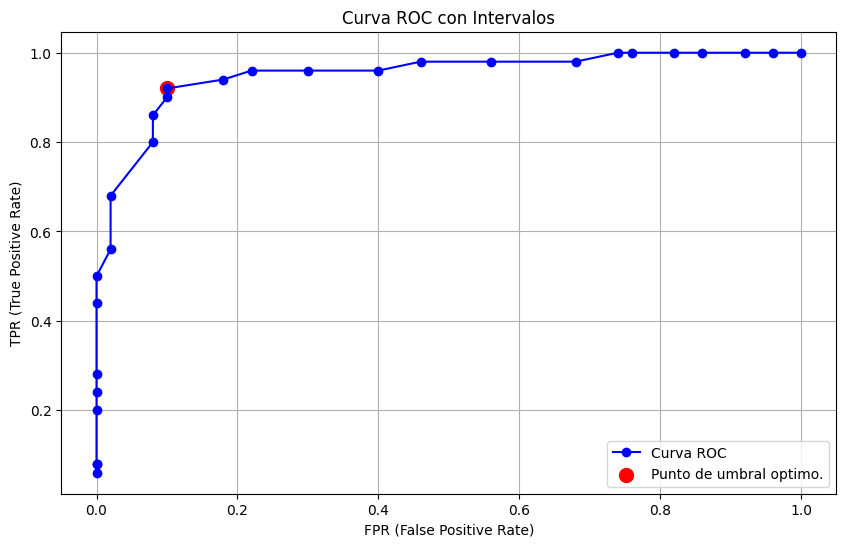

In [153]:
df_curva = curva_ROC(min(x_A),max(x_B), 0.2,df)

# calcular el Indice de Indice de Youden=Sensibilidad+Especificidad−1 para ver cual es el mejor umbral
indice_youden = []

for i in range(len(df_curva)):
  indice = df_curva['TPR(Sensibilidad)'][i] + df_curva['TNR(Especificidad)'][i] - 1
  indice_youden.append(indice)

df_curva['Indice de Youden'] = indice_youden

#Calcula elpunto con la menor distancia al punto(0,1)
distancia = []
for i in range(len(df_curva)):
  dist = np.round(np.sqrt((df_curva['FPR'][i])**2 + (1-df_curva['TPR(Sensibilidad)'][i])**2),2)
  distancia.append(dist)

df_curva['Distancia'] = distancia

print(df_curva.sort_values(by='Indice de Youden', ascending=False).head(5))

# Encontrar el índice del valor máximo en la columna 'Indice de Youden'
indice_max = df_curva['Indice de Youden'].idxmax()

# Obtener el punto específico
x_punto = df_curva.loc[indice_max, 'FPR']
y_punto = df_curva.loc[indice_max, 'TPR(Sensibilidad)']


# Crear el gráfico con matplotlib
plt.figure(figsize=(10, 6))
plt.plot(fpr_values, tpr_values, marker='o', linestyle='-', color='b', label='Curva ROC')
plt.scatter(x_punto, y_punto, color='red', s=100, label='Punto de umbral optimo.')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Curva ROC con Intervalos')
plt.grid(True)
plt.legend()
plt.show()


